In [1]:
import scanpy as sc
import anndata as ad
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.stats.multitest import multipletests
from collections import defaultdict
import pickle
from tqdm.notebook import tqdm

In [2]:
adata = sc.read('../data/simulation/TM_subset_cnt.h5ad')
ct_cnt = adata.obs['cell_type'].value_counts()
cts = ct_cnt[ct_cnt >= 40].index.values

In [3]:
def plot(res_df, color='#1f77b4', outfile=None, title=None):
    res_arr = np.asarray(res_df, np.float32)
    
    # mc calibration
    M = res_arr.shape[1]
    
    # sort each row to form empirical quantiles
    sorted_ppp = np.sort(res_arr, axis=1)
    obs = -np.log10(sorted_ppp)                          # observed curves
    exp = -np.log10( (np.arange(1, M+1) / (M+1)) )       # uniform reference
    
    # summarize
    mean_curve = obs.mean(axis=0)
    lo = np.percentile(obs, 5, axis=0)
    hi = np.percentile(obs, 95,axis=0)
    
    # plot
    plt.figure(figsize=(4,4))
    plt.plot(exp, mean_curve, color=color, lw=2)
    plt.fill_between(exp, lo, hi, color=color, alpha=0.25)
    plt.plot(exp, exp, "k--", lw=1)
    plt.xlabel("Expected -log10(p)", fontsize=14)
    plt.ylabel("Observed -log10(p)", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title("")
    plt.xlim(0.0, 3.0)
    plt.ylim(0.0, 3.5)

    if title is not None:
        plt.title(title, fontsize=14)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    else:
        plt.show()

def plot_qq_by_ct_size(res_df, ct_cnt, n_bins=5, outfile=None, title=None):
    """
    QQ plot stratified by cell type size quantiles.

    Parameters
    ----------
    res_df : DataFrame
        Rows = cell types, columns = runs, values = p-values
    ct_cnt : Series
        Cell type counts (index must match res_df index)
    n_bins : int
        Number of quantile bins (default=5)
    """

    # Align counts
    ct_cnt = ct_cnt.loc[res_df.index]

    # Create quantile bins
    bins = pd.qcut(ct_cnt, q=n_bins, duplicates="drop")

    plt.figure(figsize=(4,4))

    for b in bins.cat.categories:
        ct_in_bin = bins[bins == b].index
        if len(ct_in_bin) == 0:
            continue

        # Extract p-values for these cell types across all runs
        sub_p = res_df.loc[ct_in_bin].to_numpy(dtype=np.float32)

        # Flatten across cell types × runs
        pvals = sub_p.flatten()
        pvals = pvals[~np.isnan(pvals)]

        if len(pvals) == 0:
            continue

        M = len(pvals)

        sorted_p = np.sort(pvals)
        obs = -np.log10(sorted_p)
        exp = -np.log10((np.arange(1, M+1) / (M+1)))

        size_range = f"{int(ct_cnt[ct_in_bin].min())}-{int(ct_cnt[ct_in_bin].max())}"
        plt.plot(exp, obs, lw=2, label=f"n={size_range}")

    # Diagonal
    max_lim = 4
    plt.plot([0, max_lim], [0, max_lim], "k--", lw=1)

    plt.xlabel("Expected -log10(p)", fontsize=14)
    plt.ylabel("Observed -log10(p)", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Cell type size", fontsize=10)
    plt.xlim(0, 3.0)
    plt.ylim(0, 3.5)
    plt.tight_layout()

    if title is not None:
        plt.title(title, fontsize=14)

    if outfile:
        plt.savefig(outfile)
    else:
        plt.show()

## ICePop MC

## mc 75

In [4]:
dfs = []
files = Path('../results/icepop_null_mc-75').rglob('metacell*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["metacell", "p"])
    dfs.append(df)
mc_res = pd.concat(dfs, axis=1)
mc_res = np.asarray(mc_res, np.float32)

  0%|          | 0/10000 [00:00<?, ?it/s]

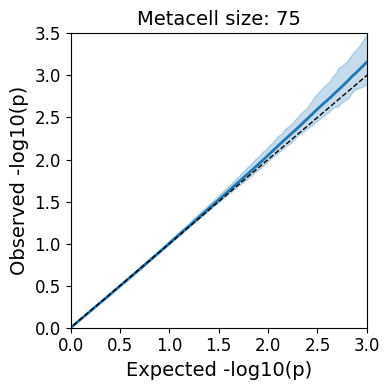

In [5]:
plot(mc_res, outfile='../paper/supp/null_icepop_mc-75.pdf', title='Metacell size: 75')

## mc 50

In [6]:
dfs = []
files = Path('../results/icepop_null_mc-50').rglob('metacell*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["metacell", "p"])
    dfs.append(df)
mc_res = pd.concat(dfs, axis=1)
mc_res = np.asarray(mc_res, np.float32)

  0%|          | 0/10000 [00:00<?, ?it/s]

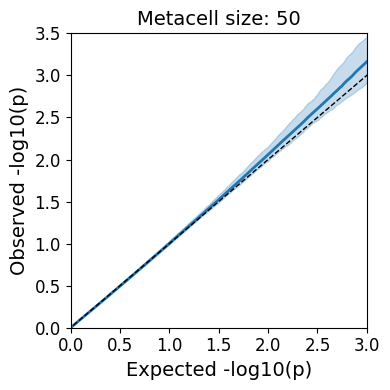

In [7]:
plot(mc_res, outfile='../paper/supp/null_icepop_mc-50.pdf', title='Metacell size: 50')

## mc 30

In [8]:
dfs = []
files = Path('../results/icepop_null_mc-30').rglob('metacell*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["metacell", "p"])
    dfs.append(df)
mc_res = pd.concat(dfs, axis=1)
mc_res = np.asarray(mc_res, np.float32)

  0%|          | 0/10000 [00:00<?, ?it/s]

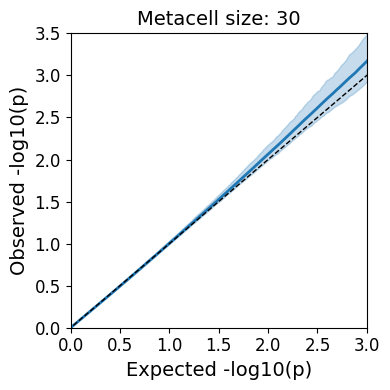

In [9]:
plot(mc_res, outfile='../paper/supp/null_icepop_mc-30.pdf', title='Metacell size: 30')

## ICePop cell type

## mc 75

In [10]:
dfs = []
files = Path('../results/icepop_null_mc-75').rglob('celltype*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["cell_type", "p"])
    dfs.append(df)
icepop_res = pd.concat(dfs, axis=1).loc[cts, :]

  0%|          | 0/10000 [00:00<?, ?it/s]

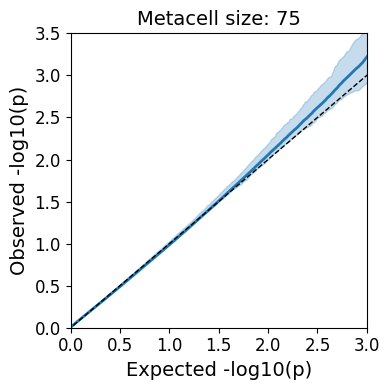

In [11]:
plot(icepop_res, outfile='../paper/supp/null_icepop_ct__mc-75.pdf', title='Metacell size: 75')

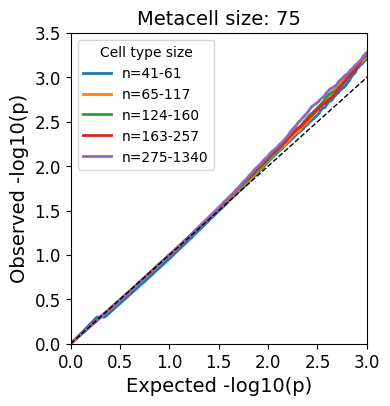

In [12]:
plot_qq_by_ct_size(icepop_res, ct_cnt, n_bins=5, outfile='../paper/supp/null_icepop_ctbin__mc-75.pdf', title='Metacell size: 75')

## mc 50

In [13]:
dfs = []
files = Path('../results/icepop_null_mc-50').rglob('celltype*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["cell_type", "p"])
    dfs.append(df)
icepop_res = pd.concat(dfs, axis=1).loc[cts, :]

  0%|          | 0/10000 [00:00<?, ?it/s]

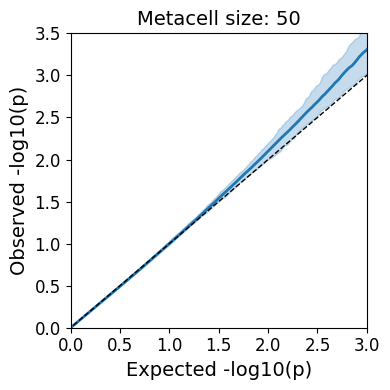

In [14]:
plot(icepop_res, outfile='../paper/supp/null_icepop_ct__mc-50.pdf', title='Metacell size: 50')

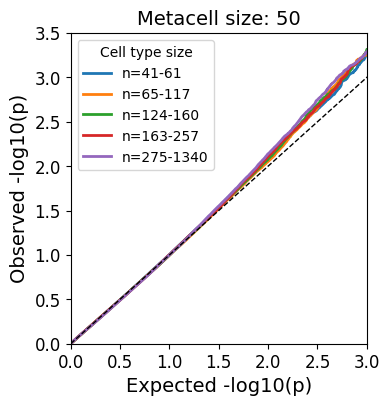

In [15]:
plot_qq_by_ct_size(icepop_res, ct_cnt, n_bins=5, outfile='../paper/supp/null_icepop_ctbin__mc-50.pdf', title='Metacell size: 50')

## mc 30

In [16]:
dfs = []
files = Path('../results/icepop_null_mc-30').rglob('celltype*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["cell_type", "p"])
    dfs.append(df)
icepop_res = pd.concat(dfs, axis=1).loc[cts, :]

  0%|          | 0/10000 [00:00<?, ?it/s]

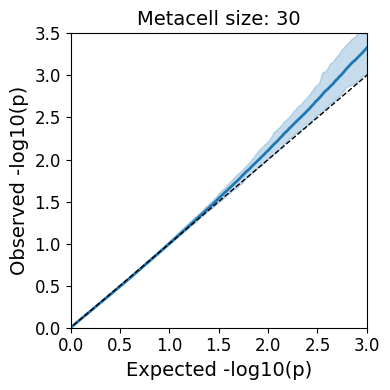

In [17]:
plot(icepop_res, outfile='../paper/supp/null_icepop_ct__mc-30.pdf', title='Metacell size: 30')

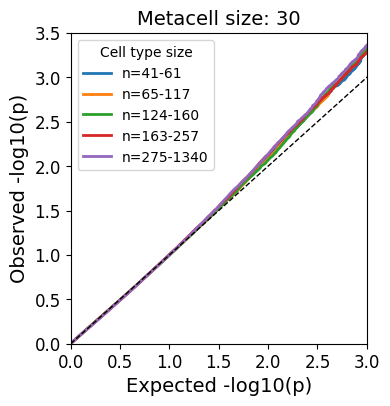

In [18]:
plot_qq_by_ct_size(icepop_res, ct_cnt, n_bins=5, outfile='../paper/supp/null_icepop_ctbin__mc-30.pdf', title='Metacell size: 30')

## Seismic

In [19]:
dfs = []
files = Path('../results/seismic_null/').rglob('*.tsv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, sep='\t', usecols=["cell_type", "pvalue"])
    dfs.append(df)
seismic_res = pd.concat(dfs, axis=1).loc[cts, :]

  0%|          | 0/10000 [00:00<?, ?it/s]

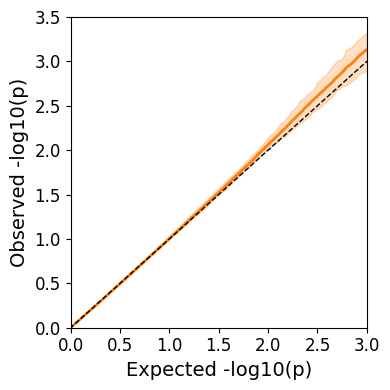

In [20]:
plot(seismic_res, color='#ff7f0e', outfile='../paper/supp/null_seismic_ct.pdf')

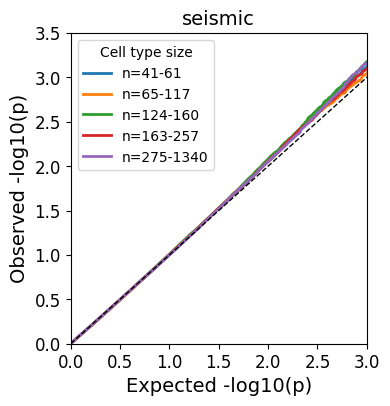

In [27]:
plot_qq_by_ct_size(seismic_res, ct_cnt, n_bins=5, outfile='../paper/supp/null_seismic_ctbin.pdf', title='seismic')

## scDRS

In [22]:
dfs = []
files = Path('../results/scdrs_null_downstream').glob('*.cell_type')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, sep='\t', usecols=["group", "assoc_mcp"])
    dfs.append(df)
scdrs_res = pd.concat(dfs, axis=1).loc[cts, :]

  0%|          | 0/10000 [00:00<?, ?it/s]

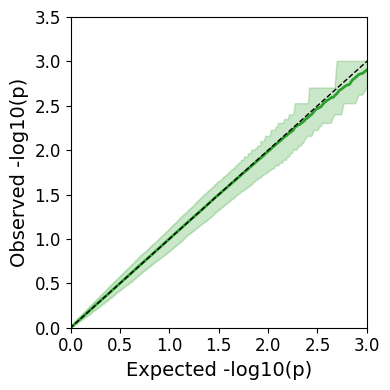

In [23]:
plot(scdrs_res, color='#2ca02c', outfile='../paper/supp/null_scdrs_ct.pdf')

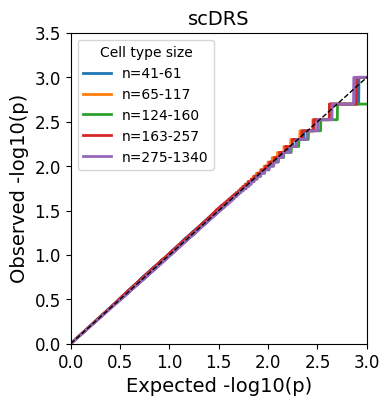

In [26]:
plot_qq_by_ct_size(scdrs_res, ct_cnt, n_bins=5, outfile='../paper/supp/null_scdrs_ctbin.pdf', title='scDRS')